In [15]:
import numpy
import pandas
import seaborn

In [28]:
df = pandas.read_csv('times.csv', index_col=0)
df['batch_size'] = numpy.log2(df['batch_size'])
df['time'] = numpy.log2(df['time'])
df

,batch_size,convergence_check,device,history,preload_data,time
0,6.0,True,cuda:1,True,True,4.168274
1,6.0,True,cuda:1,True,False,4.013036
2,6.0,True,cuda:1,False,True,4.031569
3,6.0,True,cuda:1,False,False,4.009846
4,6.0,True,cpu,True,True,4.164800
...,...,...,...,...,...,...
107,12.0,False,cuda:1,False,False,0.799571
108,12.0,False,cpu,True,True,3.571119
109,12.0,False,cpu,True,False,3.532902
110,12.0,False,cpu,False,True,1.726634


In [42]:
from sklearn.linear_model import LinearRegression

def get_lin_coef(df):
    X = pandas.get_dummies(df.drop('time', axis=1), drop_first=True)
    #y = numpy.log2(df['time'])
    y = df['time']
    m = LinearRegression().fit(X, y)
    coef = pandas.Series(m.coef_, index=X.columns)
    return coef.sort_values()


get_lin_coef(df)

device_cuda:1       -1.041661
batch_size          -0.344075
convergence_check   -0.008140
preload_data         0.010266
history              0.803746
dtype: float64

In [43]:
get_lin_coef(df.query('device == "cuda:1"'))

batch_size          -0.503585
convergence_check    0.040280
preload_data         0.049710
history              0.070370
dtype: float64

In [44]:
get_lin_coef(df.query('device == "cpu"'))

batch_size          -0.184566
convergence_check   -0.056560
preload_data        -0.029177
history              1.537122
dtype: float64

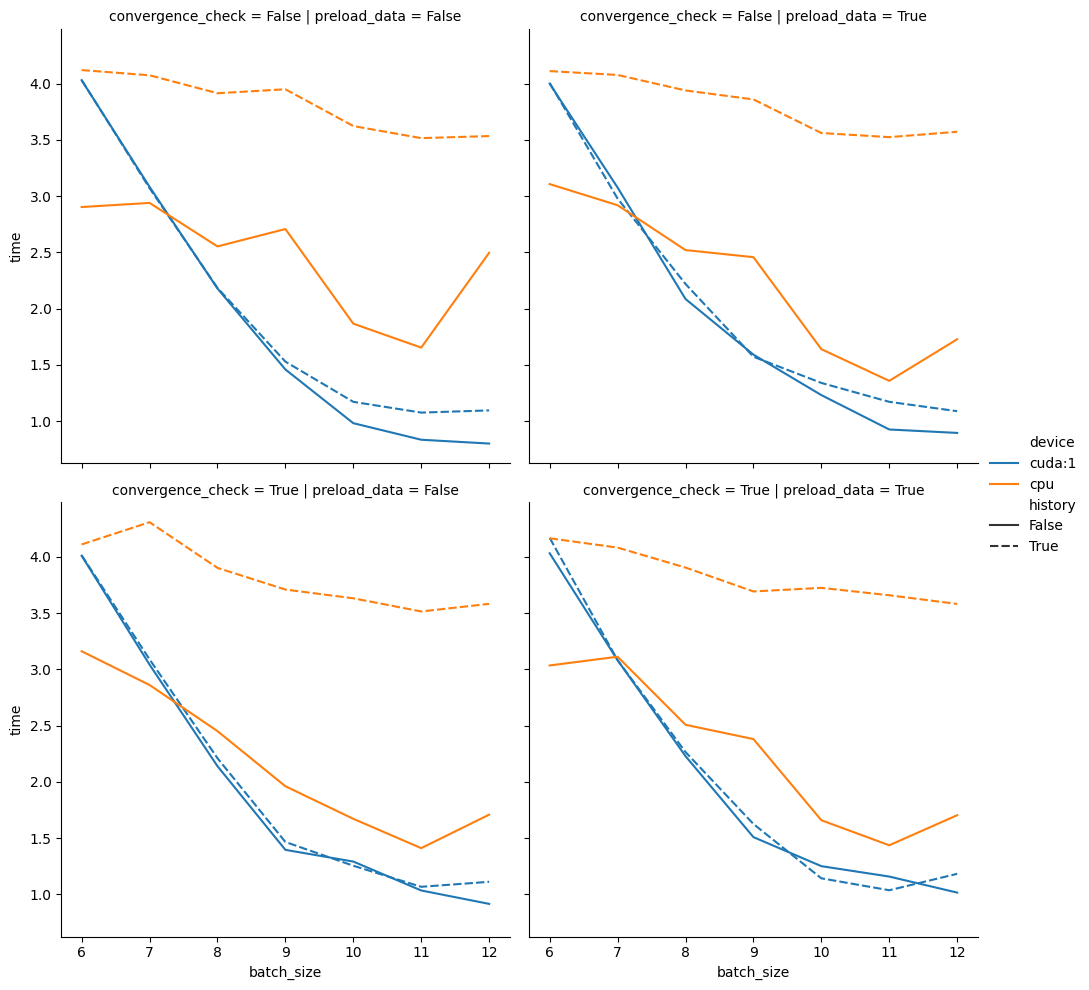

In [39]:
seaborn.relplot(df, x='batch_size', y='time', hue='device', style='history', col='preload_data', row='convergence_check', kind='line')

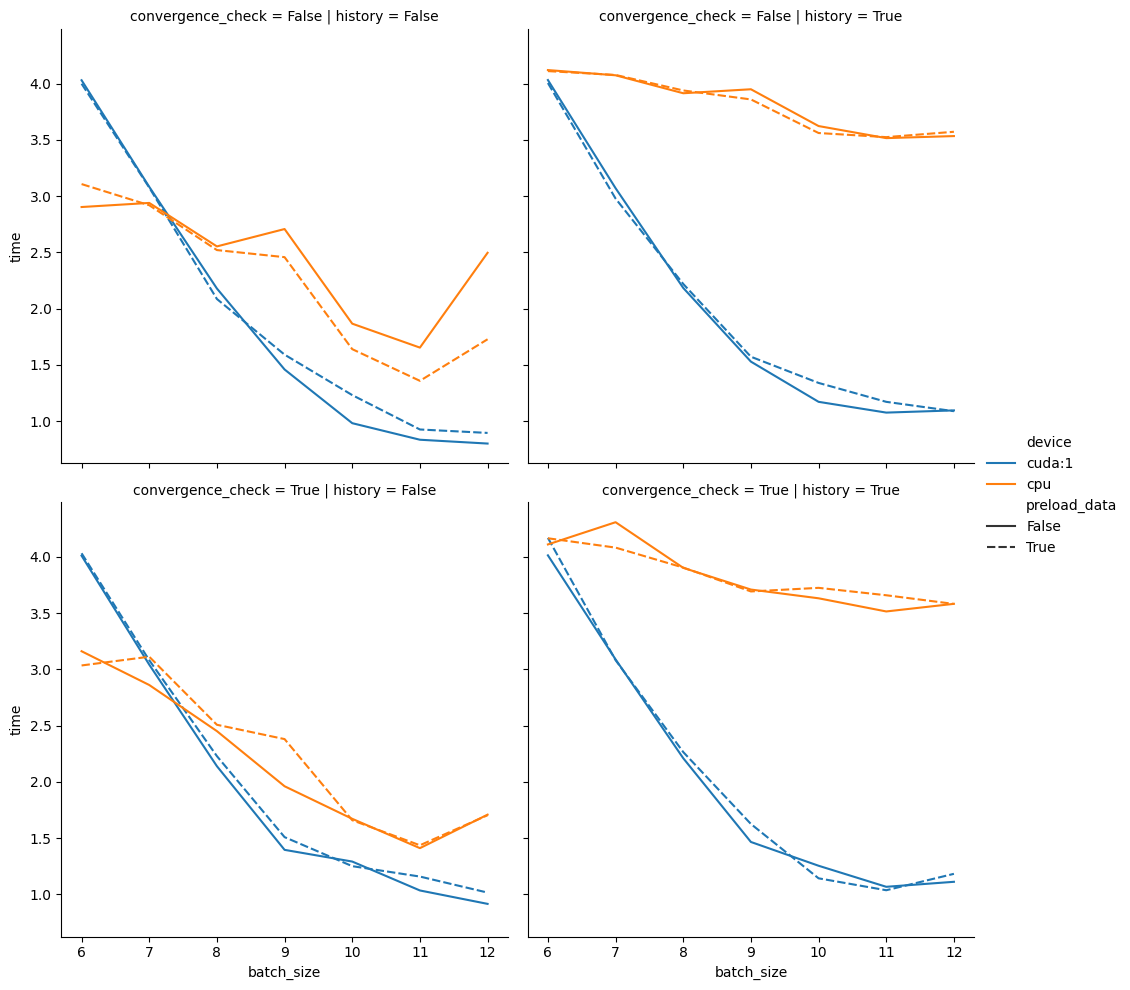

In [45]:
seaborn.relplot(df, x='batch_size', y='time', hue='device', style='preload_data', col='history', row='convergence_check', kind='line')

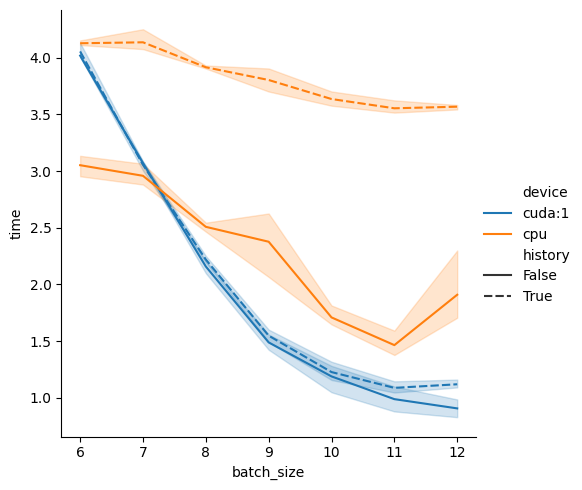

In [40]:
seaborn.relplot(df, x='batch_size', y='time', hue='device', style='history', kind='line')

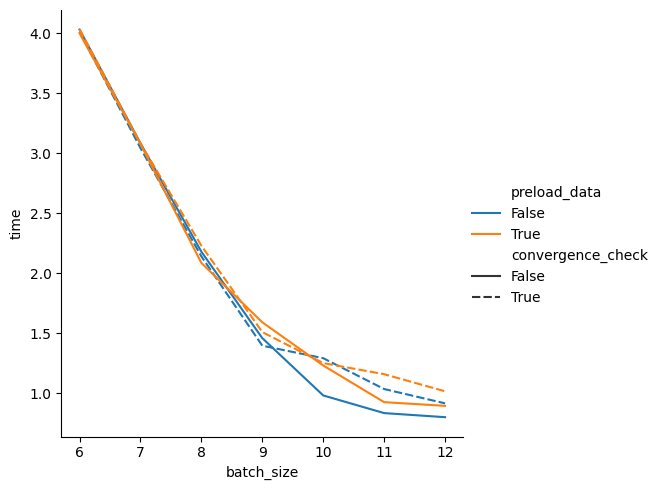

In [46]:
seaborn.relplot(df.query('history == False and device == "cuda:1"'), x='batch_size', y='time', hue='preload_data', style='convergence_check', kind='line')

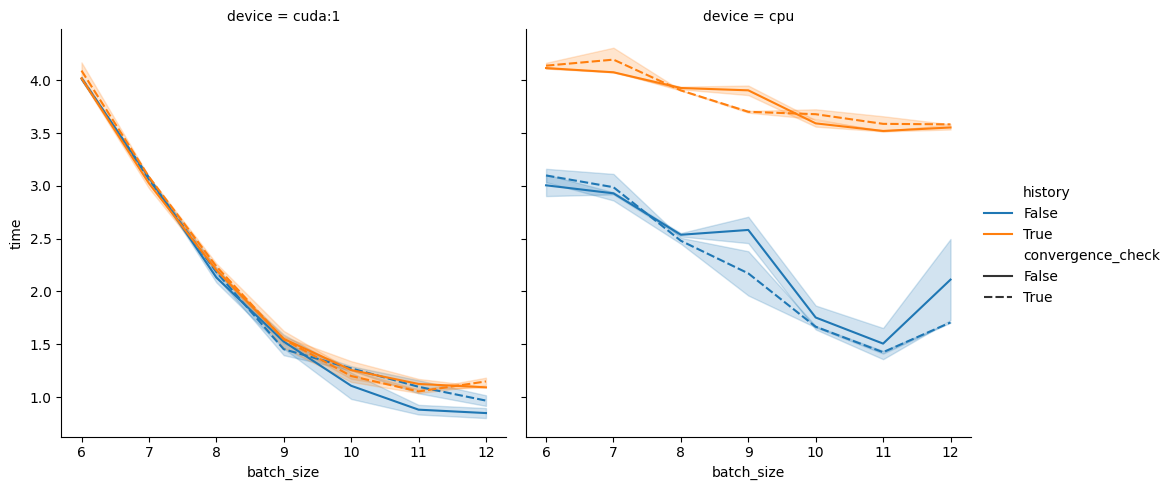

In [41]:
seaborn.relplot(df, x='batch_size', y='time', hue='history', style='convergence_check', col='device', kind='line')